# Weather Anomaly — Exploration
EDA notebook: inspect raw data, prototype z-score labeling, and select features for the model.

In [21]:
import sys
import os

# Make src/ importable from notebooks/
sys.path.insert(0, os.path.abspath(".."))

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.fetch import fetch_weather, load_weather
from src.utils.config import ANOMALY_THRESHOLD_STD, DAILY_VARS, HOURLY_VARS

%matplotlib inline
sns.set_theme(style="darkgrid")

## 1. Load Data
Use `load_weather()` if CSVs already exist, otherwise fetch from the API.

In [23]:
try:
    hourly_df, daily_df = load_weather()
    print("Loaded from disk.")
except FileNotFoundError:
    print("Fetching from API...")
    hourly_df, daily_df = fetch_weather()
    print("Done.")

print(f"Hourly: {hourly_df.shape}  |  Daily: {daily_df.shape}")
print(f"Date range: {hourly_df.index.min()} → {hourly_df.index.max()}")

Loaded from disk.
Hourly: (143280, 33)  |  Daily: (5970, 16)
Date range: 2010-01-01 06:00:00+00:00 → 2026-05-07 05:00:00+00:00


## 2. Inspect Shape, Types, and Nulls

In [24]:
hourly_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 143280 entries, 2010-01-01 06:00:00+00:00 to 2026-05-07 05:00:00+00:00
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   temperature_2m              143280 non-null  float64
 1   apparent_temperature        143280 non-null  float64
 2   dew_point_2m                143280 non-null  float64
 3   relative_humidity_2m        143280 non-null  float64
 4   precipitation               143280 non-null  float64
 5   rain                        143280 non-null  float64
 6   showers                     143280 non-null  float64
 7   snowfall                    143280 non-null  float64
 8   snow_depth                  143280 non-null  float64
 9   wind_speed_10m              143280 non-null  float64
 10  wind_speed_80m              0 non-null       float64
 11  wind_gusts_10m              143280 non-null  float64
 12  wind_direction_10m          143280 no

In [25]:
daily_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5970 entries, 2010-01-01 06:00:00+00:00 to 2026-05-06 06:00:00+00:00
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   temperature_2m_max             5970 non-null   float64
 1   temperature_2m_min             5970 non-null   float64
 2   temperature_2m_mean            5970 non-null   float64
 3   apparent_temperature_max       5970 non-null   float64
 4   apparent_temperature_min       5970 non-null   float64
 5   precipitation_sum              5970 non-null   float64
 6   rain_sum                       5970 non-null   float64
 7   snowfall_sum                   5970 non-null   float64
 8   precipitation_hours            5970 non-null   float64
 9   precipitation_probability_max  0 non-null      float64
 10  wind_speed_10m_max             5970 non-null   float64
 11  wind_gusts_10m_max             5970 non-null   float64
 12  wind_direct

In [26]:
hourly_nulls = hourly_df.isnull().sum()
daily_nulls  = daily_df.isnull().sum()

print("=== Hourly nulls ===")
print(hourly_nulls[hourly_nulls > 0].to_string() or "None")
print("\n=== Daily nulls ===")
print(daily_nulls[daily_nulls > 0].to_string() or "None")

=== Hourly nulls ===
wind_speed_80m                143280
cape                          143280
freezing_level_height         143280
visibility                    143280
temperature_850hPa            143280
relative_humidity_850hPa      143280
wind_speed_850hPa             143280
geopotential_height_850hPa    143280
temperature_500hPa            143280
wind_speed_500hPa             143280
geopotential_height_500hPa    143280
wind_speed_300hPa             143280
geopotential_height_300hPa    143280

=== Daily nulls ===
precipitation_probability_max    5970
uv_index_max                     5970


In [27]:
hourly_df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,143280.0,9.626461,11.941909,-36.450000,0.369500,9.700000,18.519500,38.700000
apparent_temperature,143280.0,6.608020,13.055051,-42.879870,-3.657887,6.547629,16.883688,36.848550
dew_point_2m,143280.0,-1.398846,8.654849,-40.000000,-7.500000,-1.750000,5.550000,20.650000
relative_humidity_2m,143280.0,53.235278,23.393629,2.634216,33.821393,54.174294,72.079010,100.000000
precipitation,143280.0,0.051969,0.276712,0.000000,0.000000,0.000000,0.000000,11.500000
rain,143280.0,0.034516,0.241618,0.000000,0.000000,0.000000,0.000000,11.500000
showers,143280.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
snowfall,143280.0,0.012499,0.087410,0.000000,0.000000,0.000000,0.000000,3.500000
snow_depth,143280.0,0.021243,0.044791,0.000000,0.000000,0.000000,0.020000,0.310000
wind_speed_10m,143280.0,8.389166,4.855985,0.000000,5.116561,7.579261,10.630672,75.550260


In [28]:
daily_df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m_max,5970.0,17.573151,11.117489,-19.500000,8.977125,18.119501,27.150000,38.700000
temperature_2m_min,5970.0,2.444139,10.082255,-36.450000,-4.800000,2.400000,11.450000,22.350000
temperature_2m_mean,5970.0,9.626461,10.594834,-23.424246,1.100042,9.726041,19.106290,29.152084
apparent_temperature_max,5970.0,14.894098,12.276814,-24.106775,4.999071,15.230822,25.847897,36.848550
apparent_temperature_min,5970.0,-0.828488,11.416566,-42.879870,-9.238502,-1.270900,9.453125,21.564274
precipitation_sum,5970.0,1.247253,3.536419,0.000000,0.000000,0.000000,0.600000,49.800000
rain_sum,5970.0,0.828375,2.892505,0.000000,0.000000,0.000000,0.200000,49.800000
snowfall_sum,5970.0,0.299968,1.296136,0.000000,0.000000,0.000000,0.000000,23.099998
precipitation_hours,5970.0,2.166834,4.325387,0.000000,0.000000,0.000000,2.000000,24.000000
precipitation_probability_max,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2b. Time-Series Continuity Check
Verify no hours or days are missing from the index. A gap means `shift(1)` / `shift(-1)` lag features would silently jump across the boundary — we need to know before building any lag-based features.

In [29]:
# ── Continuity check: are any hours or days missing from the date range? ──────
# Determines whether lag features (hour+1, day+1) are safe to use without fills.

expected_hourly = pd.date_range(
    start=hourly_df.index.min(),
    end=hourly_df.index.max(),
    freq="h",
    tz=hourly_df.index.tz,
)
expected_daily = pd.date_range(
    start=daily_df.index.min(),
    end=daily_df.index.max(),
    freq="24h",
    tz=daily_df.index.tz,
)

missing_hours = expected_hourly.difference(hourly_df.index)
missing_days  = expected_daily.difference(daily_df.index)

# Detect consecutive gaps by diffing the index itself
hourly_step = pd.Series(hourly_df.index).diff().dt.total_seconds().div(3600)
daily_step  = pd.Series(daily_df.index).diff().dt.total_seconds().div(86400)

hourly_gap_locs = hourly_step[hourly_step > 1].dropna()
daily_gap_locs  = daily_step[daily_step > 1].dropna()

# ── Report ────────────────────────────────────────────────────────────────────
print(f"Hourly  {hourly_df.index.min()} → {hourly_df.index.max()}")
print(f"  Expected : {len(expected_hourly):,} rows")
print(f"  Actual   : {len(hourly_df):,} rows")
print(f"  Missing  : {len(missing_hours)} timestamps")
print(f"  Gaps > 1h: {len(hourly_gap_locs)}")
if not hourly_gap_locs.empty:
    gap_tbl = pd.DataFrame({
        "gap_hours":       hourly_gap_locs.values,
        "gap_starts_after": hourly_df.index[hourly_gap_locs.index - 1],
    }).sort_values("gap_hours", ascending=False)
    print(gap_tbl.head(10).to_string(index=False))

print()
print(f"Daily   {daily_df.index.min()} → {daily_df.index.max()}")
print(f"  Expected : {len(expected_daily):,} rows")
print(f"  Actual   : {len(daily_df):,} rows")
print(f"  Missing  : {len(missing_days)} timestamps")
print(f"  Gaps > 1d: {len(daily_gap_locs)}")
if not daily_gap_locs.empty:
    gap_tbl_d = pd.DataFrame({
        "gap_days":        daily_gap_locs.values,
        "gap_starts_after": daily_df.index[daily_gap_locs.index - 1],
    }).sort_values("gap_days", ascending=False)
    print(gap_tbl_d.head(10).to_string(index=False))

# ── Verdict ───────────────────────────────────────────────────────────────────
print("\n── Verdict ──────────────────────────────────────────────────────────────")
if len(missing_hours) == 0 and hourly_gap_locs.empty:
    print("  Hourly: COMPLETE  — hour+1 always exists; no fills needed for lag features.")
else:
    print(f"  Hourly: GAPS FOUND — {len(missing_hours)} missing hours across {len(hourly_gap_locs)} gap(s).")
    print("           Forward-fill or interpolation required before constructing lag features.")

if len(missing_days) == 0 and daily_gap_locs.empty:
    print("  Daily:  COMPLETE  — day+1 always exists; no fills needed for lag features.")
else:
    print(f"  Daily:  GAPS FOUND — {len(missing_days)} missing days across {len(daily_gap_locs)} gap(s).")
    print("           Forward-fill required before constructing lag features.")

Hourly  2010-01-01 06:00:00+00:00 → 2026-05-07 05:00:00+00:00
  Expected : 143,280 rows
  Actual   : 143,280 rows
  Missing  : 0 timestamps
  Gaps > 1h: 0

Daily   2010-01-01 06:00:00+00:00 → 2026-05-06 06:00:00+00:00
  Expected : 5,970 rows
  Actual   : 5,970 rows
  Missing  : 0 timestamps
  Gaps > 1d: 0

── Verdict ──────────────────────────────────────────────────────────────
  Hourly: COMPLETE  — hour+1 always exists; no fills needed for lag features.
  Daily:  COMPLETE  — day+1 always exists; no fills needed for lag features.


## 3. Time Series Plots
Visual sanity check on the primary signals.

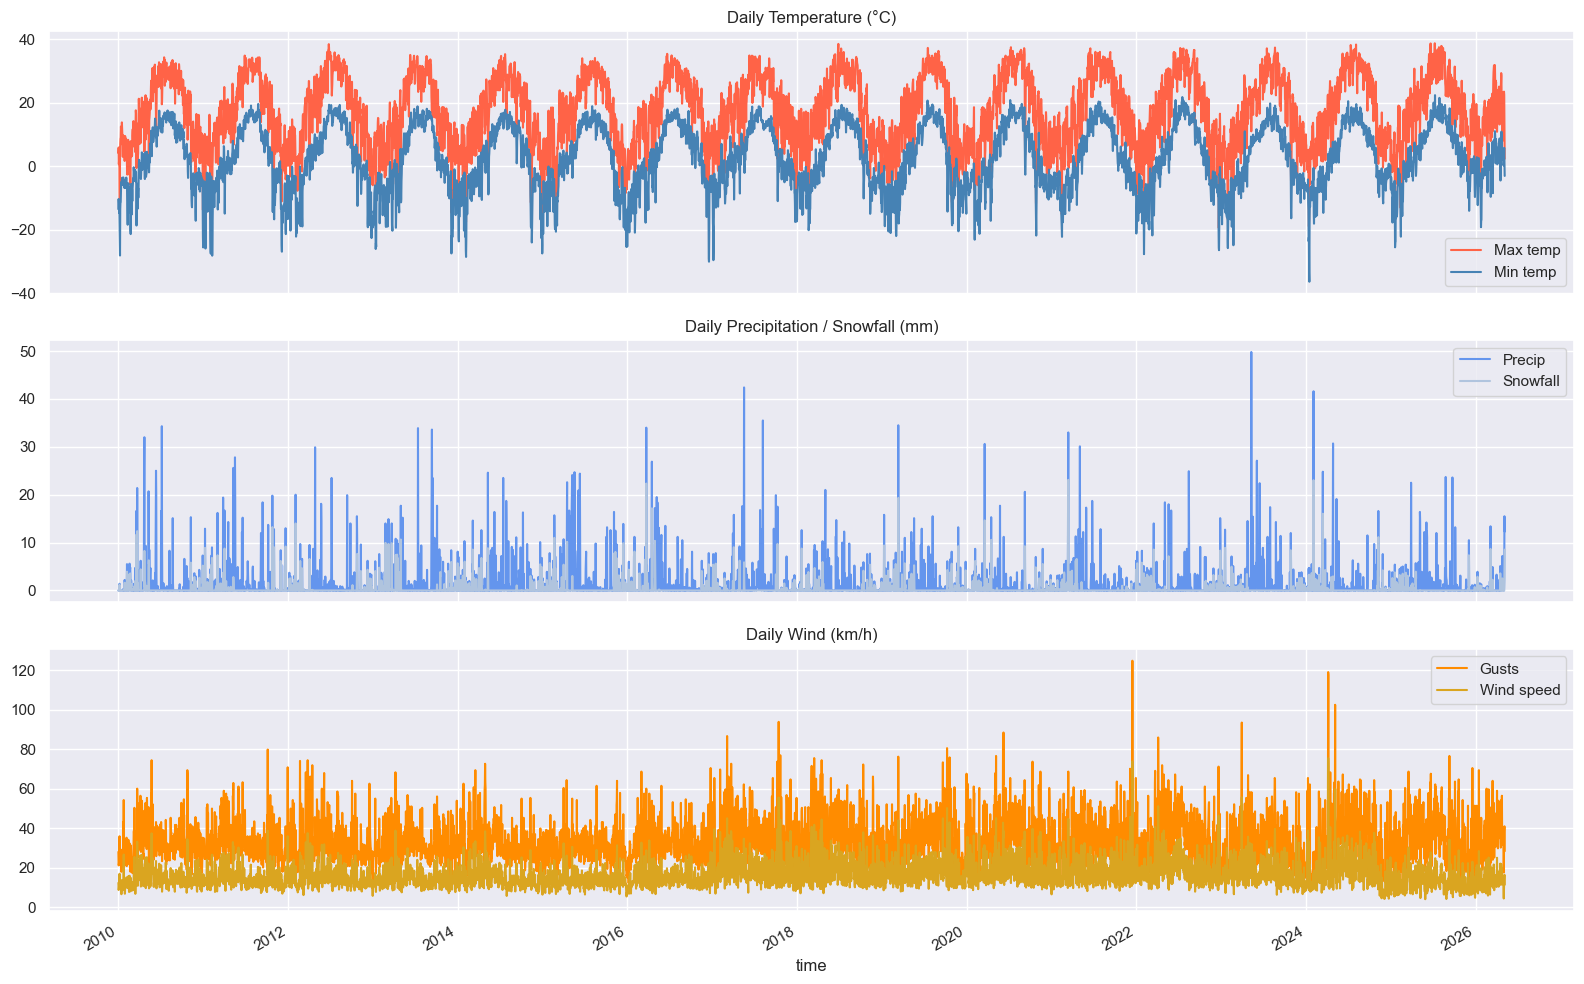

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

daily_df["temperature_2m_max"].plot(ax=axes[0], label="Max temp", color="tomato")
daily_df["temperature_2m_min"].plot(ax=axes[0], label="Min temp", color="steelblue")
axes[0].set_title("Daily Temperature (°C)")
axes[0].legend()

daily_df["precipitation_sum"].plot(ax=axes[1], label="Precip", color="cornflowerblue")
daily_df["snowfall_sum"].plot(ax=axes[1], label="Snowfall", color="lightsteelblue")
axes[1].set_title("Daily Precipitation / Snowfall (mm)")
axes[1].legend()

daily_df["wind_gusts_10m_max"].plot(ax=axes[2], label="Gusts", color="darkorange")
daily_df["wind_speed_10m_max"].plot(ax=axes[2], label="Wind speed", color="goldenrod")
axes[2].set_title("Daily Wind (km/h)")
axes[2].legend()

plt.tight_layout()

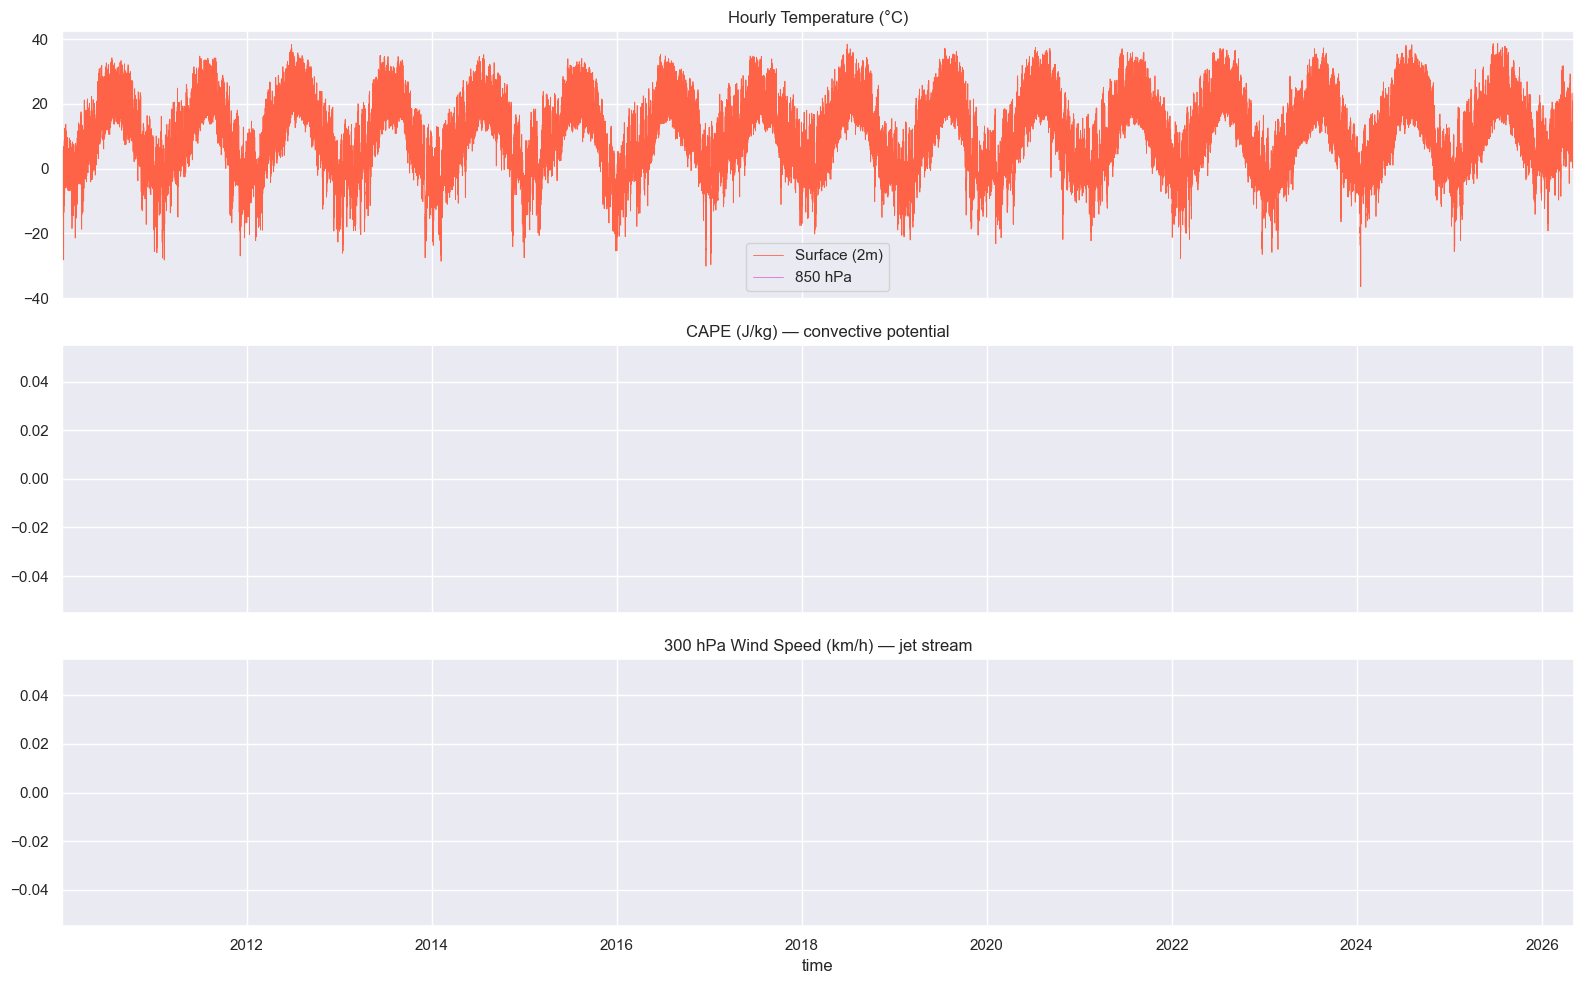

In [31]:
# Hourly temperature + upper-air signals
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

hourly_df["temperature_2m"].plot(ax=axes[0], label="Surface (2m)", color="tomato", lw=0.6)
hourly_df["temperature_850hPa"].plot(ax=axes[0], label="850 hPa", color="orchid", lw=0.6)
axes[0].set_title("Hourly Temperature (°C)")
axes[0].legend()

hourly_df["cape"].plot(ax=axes[1], color="firebrick", lw=0.6)
axes[1].set_title("CAPE (J/kg) — convective potential")

hourly_df["wind_speed_300hPa"].plot(ax=axes[2], color="slateblue", lw=0.6)
axes[2].set_title("300 hPa Wind Speed (km/h) — jet stream")

plt.tight_layout()

## 4. Z-Score Anomaly Labeling (Prototype)
Type 1 anomaly: deviation from the seasonal historical mean for each calendar day.

Logic to port into `src/data/injest.py` once validated here.

In [32]:
def compute_seasonal_zscore(series: pd.Series, window_days: int = 15) -> pd.Series:
    """Rolling seasonal z-score: compare each day to same day-of-year ± window across all years."""
    doy = series.index.day_of_year
    z = pd.Series(index=series.index, dtype=float)
    for d in range(1, 367):
        mask = (doy >= d - window_days) & (doy <= d + window_days)
        ref = series[mask]
        mu, sigma = ref.mean(), ref.std()
        target = series[doy == d]
        if sigma > 0:
            z[doy == d] = (target - mu) / sigma
    return z


daily_df["temp_max_zscore"]  = compute_seasonal_zscore(daily_df["temperature_2m_max"])
daily_df["is_temp_anomaly"]  = daily_df["temp_max_zscore"].abs() > ANOMALY_THRESHOLD_STD
daily_df["next_day_anomaly"] = daily_df["is_temp_anomaly"].shift(-1)

n_anomalies = daily_df["is_temp_anomaly"].sum()
pct = 100 * n_anomalies / len(daily_df)
print(f"Temperature anomalies flagged: {n_anomalies} / {len(daily_df)} days ({pct:.1f}%)")

Temperature anomalies flagged: 209 / 5970 days (3.5%)


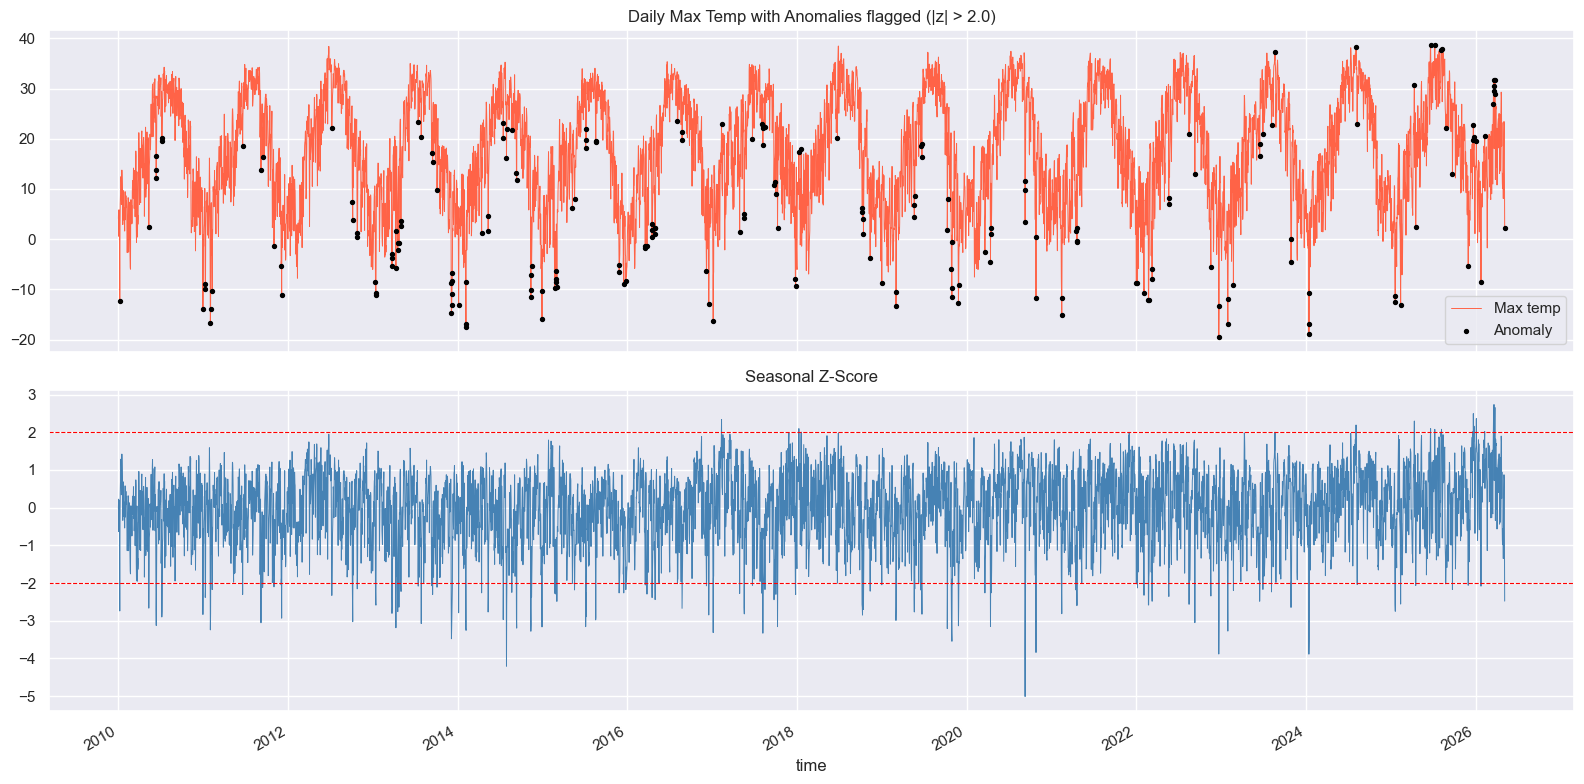

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

daily_df["temperature_2m_max"].plot(ax=axes[0], color="tomato", lw=0.7, label="Max temp")
anomaly_pts = daily_df.loc[daily_df["is_temp_anomaly"], "temperature_2m_max"]
axes[0].scatter(anomaly_pts.index, anomaly_pts.values, color="black", s=8, zorder=5, label="Anomaly")
axes[0].set_title(f"Daily Max Temp with Anomalies flagged (|z| > {ANOMALY_THRESHOLD_STD})")
axes[0].legend()

daily_df["temp_max_zscore"].plot(ax=axes[1], color="steelblue", lw=0.7)
axes[1].axhline(ANOMALY_THRESHOLD_STD, color="red", ls="--", lw=0.8)
axes[1].axhline(-ANOMALY_THRESHOLD_STD, color="red", ls="--", lw=0.8)
axes[1].set_title("Seasonal Z-Score")

plt.tight_layout()

## 5. Correlation Matrix — Daily Variables
Use this to identify redundant features and guide variable selection for the model.

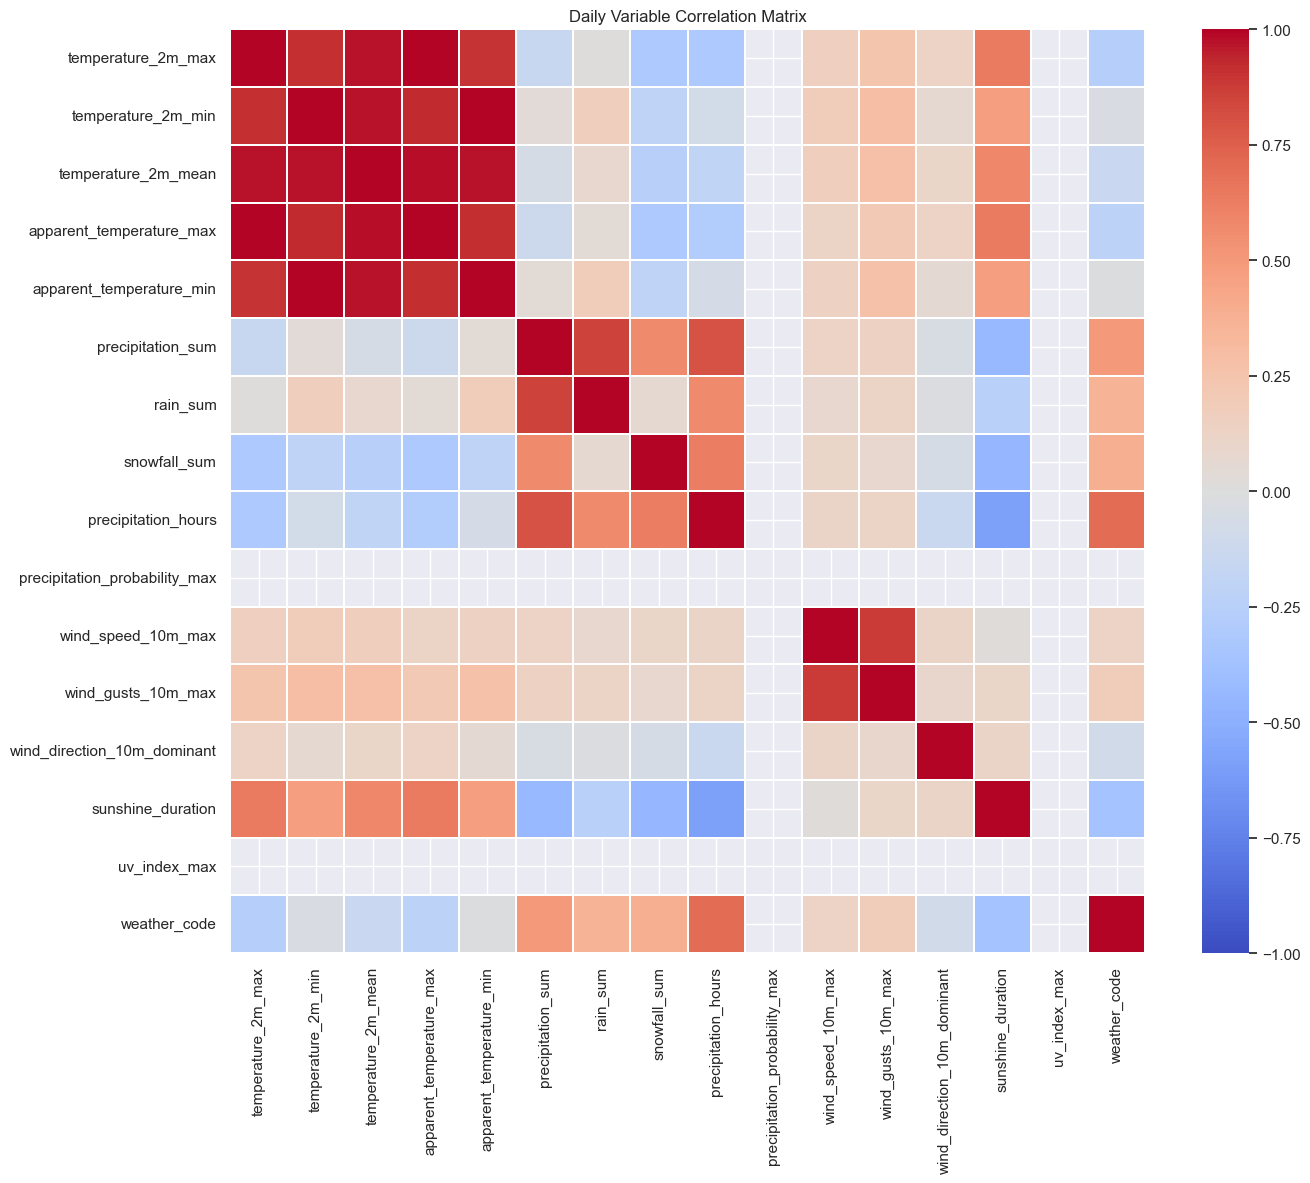

In [34]:
numeric_daily = daily_df[DAILY_VARS].select_dtypes(include="number")
corr = numeric_daily.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
)
ax.set_title("Daily Variable Correlation Matrix")
plt.tight_layout()

In [35]:
# Pairs with |r| > 0.85 — candidates for dropping one of the two
high_corr = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr[high_corr > 0.85]

temperature_2m_min        apparent_temperature_min    0.996824
temperature_2m_max        apparent_temperature_max    0.993810
temperature_2m_mean       apparent_temperature_max    0.977895
temperature_2m_max        temperature_2m_mean         0.974702
temperature_2m_min        temperature_2m_mean         0.974529
temperature_2m_mean       apparent_temperature_min    0.969699
temperature_2m_min        apparent_temperature_max    0.923718
apparent_temperature_max  apparent_temperature_min    0.920413
temperature_2m_max        temperature_2m_min          0.913863
                          apparent_temperature_min    0.906102
wind_speed_10m_max        wind_gusts_10m_max          0.877307
precipitation_sum         rain_sum                    0.854842
dtype: float64

## 6. Correlation Matrix — Hourly Variables

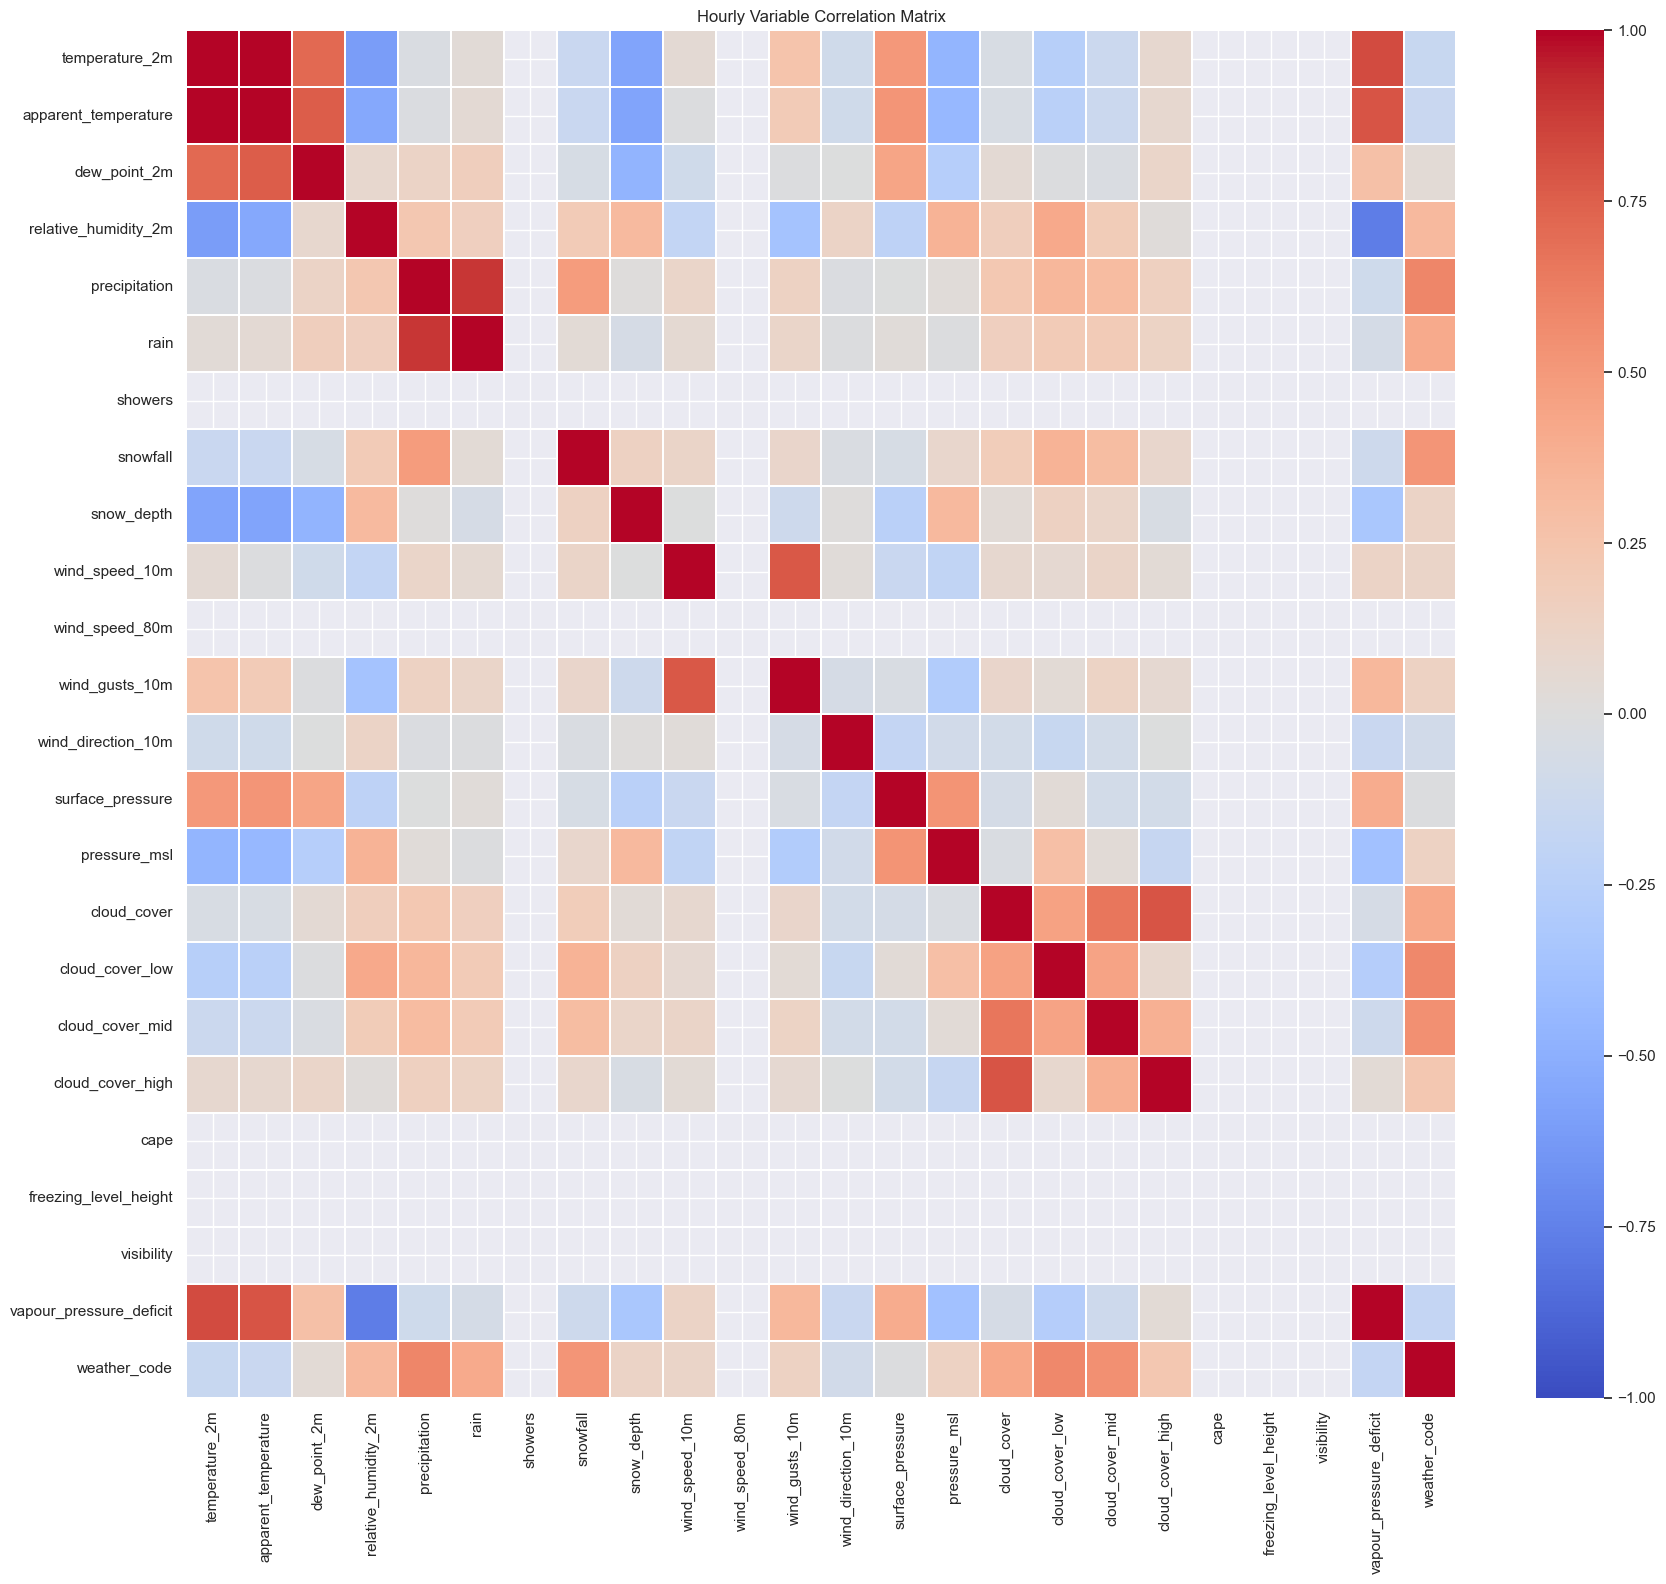

In [36]:
numeric_hourly = hourly_df[HOURLY_VARS].select_dtypes(include="number")
corr_h = numeric_hourly.corr()

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    corr_h,
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
)
ax.set_title("Hourly Variable Correlation Matrix")
plt.tight_layout()

## 7. Scratch Pad
Use cells below to iterate on cleaning logic, feature engineering, or labeling before porting to `injest.py`.

## 8. Apparent Temperature: Does it add signal beyond `temperature_2m`?
Two questions:
1. Does `apparent_temperature` itself correlate with anomalies better than raw temp?
2. Does the **offset** (`apparent_temperature − temperature_2m`) — which captures wind-chill and heat-index effects — carry independent signal?

If the offset shows a different distribution on anomaly days it justifies keeping it as a compound feature rather than raw `apparent_temperature`.

Offset stats:
count    143280.000000
mean         -3.018440
std           1.705077
min         -14.476318
25%          -4.239782
50%          -3.323370
75%          -1.875650
max           3.754045
Name: apparent_temp_diff, dtype: float64


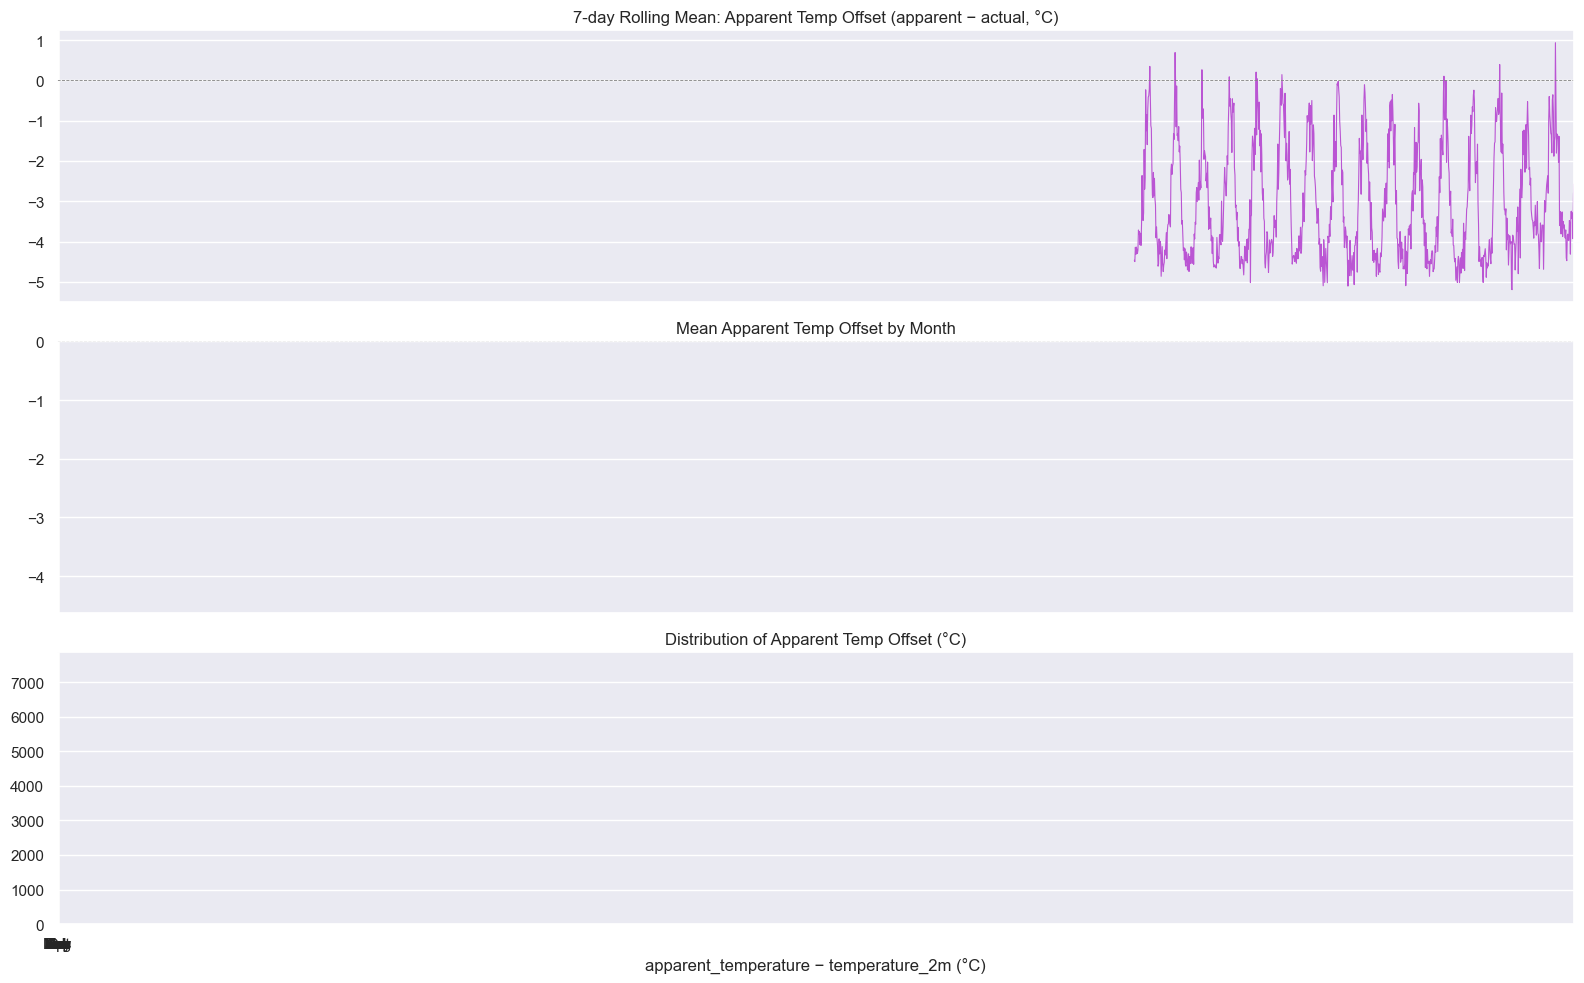

In [37]:
# Hourly: apparent_temp_diff time series and seasonal pattern
hourly_df["apparent_temp_diff"] = hourly_df["apparent_temperature"] - hourly_df["temperature_2m"]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

hourly_df["apparent_temp_diff"].resample("7D").mean().plot(
    ax=axes[0], color="mediumorchid", lw=0.8
)
axes[0].set_title("7-day Rolling Mean: Apparent Temp Offset (apparent − actual, °C)")
axes[0].axhline(0, color="gray", ls="--", lw=0.6)

# Distribution by month
monthly_offset = hourly_df["apparent_temp_diff"].groupby(hourly_df.index.month).mean()
axes[1].bar(monthly_offset.index, monthly_offset.values, color="mediumorchid", alpha=0.8)
axes[1].set_title("Mean Apparent Temp Offset by Month")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axes[1].axhline(0, color="gray", ls="--", lw=0.6)

# Overall distribution
axes[2].hist(hourly_df["apparent_temp_diff"].dropna(), bins=100,
             color="mediumorchid", alpha=0.7, edgecolor="none")
axes[2].set_title("Distribution of Apparent Temp Offset (°C)")
axes[2].set_xlabel("apparent_temperature − temperature_2m (°C)")

plt.tight_layout()
print(f"Offset stats:\n{hourly_df['apparent_temp_diff'].describe()}")

Point-biserial r with is_temp_anomaly:

  temperature_2m_max                  r=-0.2303  p=1.11e-72
  temperature_2m_min                  r=-0.1490  p=5.74e-31
  apparent_temperature_max            r=-0.2153  p=1.58e-63
  apparent_temperature_min            r=-0.1381  p=8.43e-27
  apparent_temp_diff_max              r=-0.0474  p=2.48e-04
  apparent_temp_diff_min              r=-0.0470  p=2.81e-04


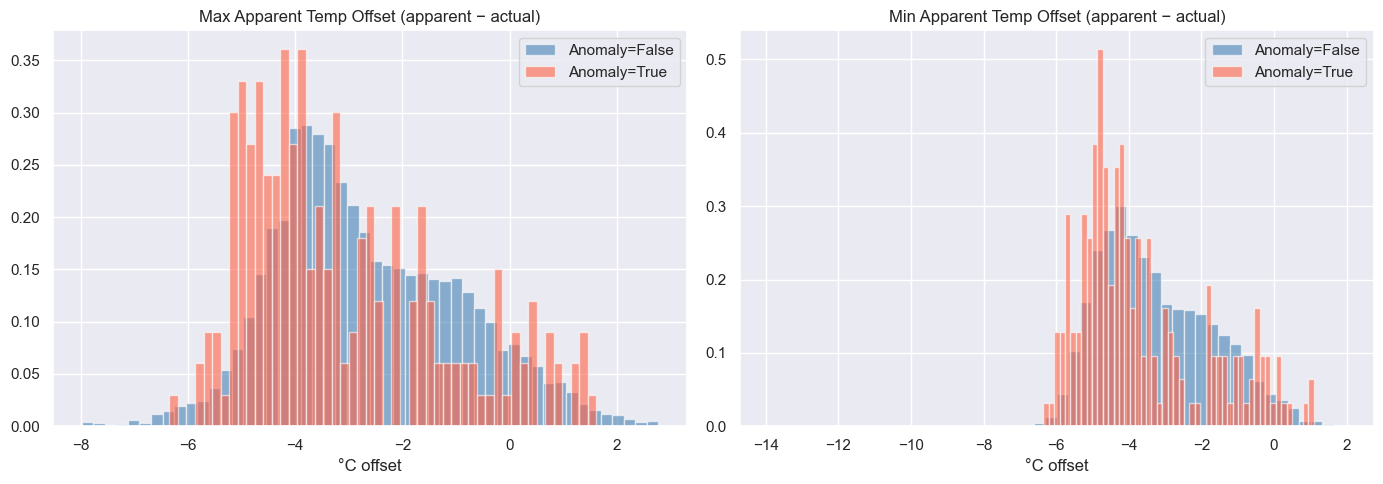

In [38]:
from scipy.stats import pointbiserialr

# Daily: compute apparent temp offsets and test correlation with anomaly flag
daily_df["apparent_temp_diff_max"] = daily_df["apparent_temperature_max"] - daily_df["temperature_2m_max"]
daily_df["apparent_temp_diff_min"] = daily_df["apparent_temperature_min"] - daily_df["temperature_2m_min"]

vars_to_test = [
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "apparent_temp_diff_max",
    "apparent_temp_diff_min",
]

print("Point-biserial r with is_temp_anomaly:\n")
for v in vars_to_test:
    valid = daily_df[[v, "is_temp_anomaly"]].dropna()
    r, p = pointbiserialr(valid["is_temp_anomaly"].astype(int), valid[v])
    print(f"  {v:<35} r={r:+.4f}  p={p:.2e}")

# Visual: distribution of apparent temp offset on anomaly vs normal days
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["apparent_temp_diff_max", "apparent_temp_diff_min"],
    ["Max Apparent Temp Offset (apparent − actual)", "Min Apparent Temp Offset (apparent − actual)"],
):
    for label, color in [(False, "steelblue"), (True, "tomato")]:
        subset = daily_df.loc[daily_df["is_temp_anomaly"] == label, col].dropna()
        ax.hist(subset, bins=50, alpha=0.6, color=color,
                label=f"Anomaly={label}", density=True)
    ax.set_title(title)
    ax.set_xlabel("°C offset")
    ax.legend()

plt.tight_layout()

## 9. Compound Variable Candidates
Engineered features that combine raw signals into more informative representations.
Each is computed on the existing dataframes, then correlated against the `is_temp_anomaly` label.

In [39]:
# ── Ratio / interaction compound variables ────────────────────────────────────
# Daily
daily_df["temp_range"]       = daily_df["temperature_2m_max"] - daily_df["temperature_2m_min"]
daily_df["precip_intensity"] = daily_df["precipitation_sum"] / (daily_df["precipitation_hours"] + 1e-3)
daily_df["snow_fraction"]    = daily_df["snowfall_sum"] / (daily_df["precipitation_sum"] + 1e-3)
daily_df["gust_ratio"]       = daily_df["wind_gusts_10m_max"] / (daily_df["wind_speed_10m_max"] + 1e-3)

# Hourly
hourly_df["dew_point_depression"] = hourly_df["temperature_2m"] - hourly_df["dew_point_2m"]
hourly_df["pressure_tendency_1h"] = hourly_df["pressure_msl"].diff(1)
hourly_df["pressure_tendency_3h"] = hourly_df["pressure_msl"].diff(3)
hourly_df["wind_momentum"]        = hourly_df["wind_speed_10m"] * hourly_df["wind_gusts_10m"]
hourly_df["cloud_stratification"] = hourly_df["cloud_cover_high"] - hourly_df["cloud_cover_low"]
hourly_df["heat_stress"]          = hourly_df["vapour_pressure_deficit"] * hourly_df["temperature_2m"].clip(lower=0)

# ── Monthly departure features (value − historical monthly climatology) ────────
# Each value is subtracted from the mean of ALL years for that calendar month,
# so the column encodes "how unusual is today relative to a typical <month>?"
_monthly_src_daily = {
    "temperature_2m_max":  "avg_temp_diff",
    "temperature_2m_min":  "avg_temp_min_diff",
    "snowfall_sum":        "avg_snow_diff",
    "precipitation_sum":   "avg_precip_diff",
    "rain_sum":            "avg_rain_diff",
    "wind_speed_10m_max":  "avg_wind_speed_diff",
    "wind_gusts_10m_max":  "avg_wind_gusts_diff",
    "sunshine_duration":   "avg_sunshine_diff",
}
for src, dest in _monthly_src_daily.items():
    monthly_clim = daily_df.groupby(daily_df.index.month)[src].transform("mean")
    daily_df[dest] = daily_df[src] - monthly_clim

_monthly_src_hourly = {
    "temperature_2m":       "avg_temp_diff",
    "pressure_msl":         "avg_pressure_diff",
    "wind_speed_10m":       "avg_wind_speed_diff",
    "relative_humidity_2m": "avg_humidity_diff",
}
for src, dest in _monthly_src_hourly.items():
    monthly_clim = hourly_df.groupby(hourly_df.index.month)[src].transform("mean")
    hourly_df[dest] = hourly_df[src] - monthly_clim

compound_vars_daily  = ["temp_range", "precip_intensity", "snow_fraction", "gust_ratio"]
avg_diff_vars_daily  = list(_monthly_src_daily.values())

compound_vars_hourly = [
    "apparent_temp_diff",
    "dew_point_depression",
    "pressure_tendency_1h",
    "pressure_tendency_3h",
    "wind_momentum",
    "cloud_stratification",
    "heat_stress",
]
avg_diff_vars_hourly = list(_monthly_src_hourly.values())

print("Ratio / interaction compounds (daily):")
ratio_desc = {
    "temp_range":          "Max − Min temp: large range = dry/clear, small = cloudy/stormy",
    "precip_intensity":    "Precip sum / precip hours: event intensity (mm/hr)",
    "snow_fraction":       "Snowfall / total precip: mixed vs snow-only events",
    "gust_ratio":          "Gusts / mean wind speed: gustiness; frontal passage signal",
}
for k, v in ratio_desc.items():
    print(f"  {k:<28} {v}")

print("\nRatio / interaction compounds (hourly):")
hourly_desc = {
    "apparent_temp_diff":    "Apparent − actual temp: wind-chill / heat-index magnitude",
    "dew_point_depression":  "Temp − dew point: lower = more humid / fog-prone",
    "pressure_tendency_1h":  "1-hr Δ pressure_msl: rapid drops precede storms",
    "pressure_tendency_3h":  "3-hr Δ pressure_msl: synoptic-scale frontal signal",
    "wind_momentum":         "Wind speed × gusts: kinetic energy proxy",
    "cloud_stratification":  "High − Low cloud cover: convective vs stable profile",
    "heat_stress":           "VPD × temp (≥0): combined heat and drought stress index",
}
for k, v in hourly_desc.items():
    print(f"  {k:<28} {v}")

print("\nMonthly departure features (daily):")
for src, dest in _monthly_src_daily.items():
    print(f"  {dest:<28} {src} − monthly climatology mean")

print("\nMonthly departure features (hourly):")
for src, dest in _monthly_src_hourly.items():
    print(f"  {dest:<28} {src} − monthly climatology mean")

Ratio / interaction compounds (daily):
  temp_range                   Max − Min temp: large range = dry/clear, small = cloudy/stormy
  precip_intensity             Precip sum / precip hours: event intensity (mm/hr)
  snow_fraction                Snowfall / total precip: mixed vs snow-only events
  gust_ratio                   Gusts / mean wind speed: gustiness; frontal passage signal

Ratio / interaction compounds (hourly):
  apparent_temp_diff           Apparent − actual temp: wind-chill / heat-index magnitude
  dew_point_depression         Temp − dew point: lower = more humid / fog-prone
  pressure_tendency_1h         1-hr Δ pressure_msl: rapid drops precede storms
  pressure_tendency_3h         3-hr Δ pressure_msl: synoptic-scale frontal signal
  wind_momentum                Wind speed × gusts: kinetic energy proxy
  cloud_stratification         High − Low cloud cover: convective vs stable profile
  heat_stress                  VPD × temp (≥0): combined heat and drought stress index

MI matrix: 5,969 rows × 28 features  (dropped 0 all-NaN columns, 0 incomplete rows)

Predictive scores vs next_day_anomaly (T → T+1):

                 variable         r      p_value  mutual_info
      h_avg_temp_diff_max -0.229993 1.708335e-72     0.035230
            avg_temp_diff -0.229819 2.198223e-72     0.033183
     h_avg_temp_diff_mean -0.220553 1.138405e-66     0.027891
        avg_sunshine_diff -0.231415 2.146210e-73     0.021288
            avg_snow_diff  0.235949 2.626493e-76     0.020367
          avg_precip_diff  0.255569 1.214211e-89     0.020229
cloud_stratification_mean -0.165130 9.360691e-38     0.019326
 h_avg_humidity_diff_mean  0.162116 1.961953e-36     0.017915
        avg_temp_min_diff -0.165398 7.127399e-38     0.017618
      h_avg_temp_diff_min -0.162025 2.147350e-36     0.016949
dew_point_depression_mean -0.135899 5.289851e-26     0.016812
         precip_intensity  0.160837 7.004445e-36     0.016419
            snow_fraction  0.027740 3.210295e-02     0.0156

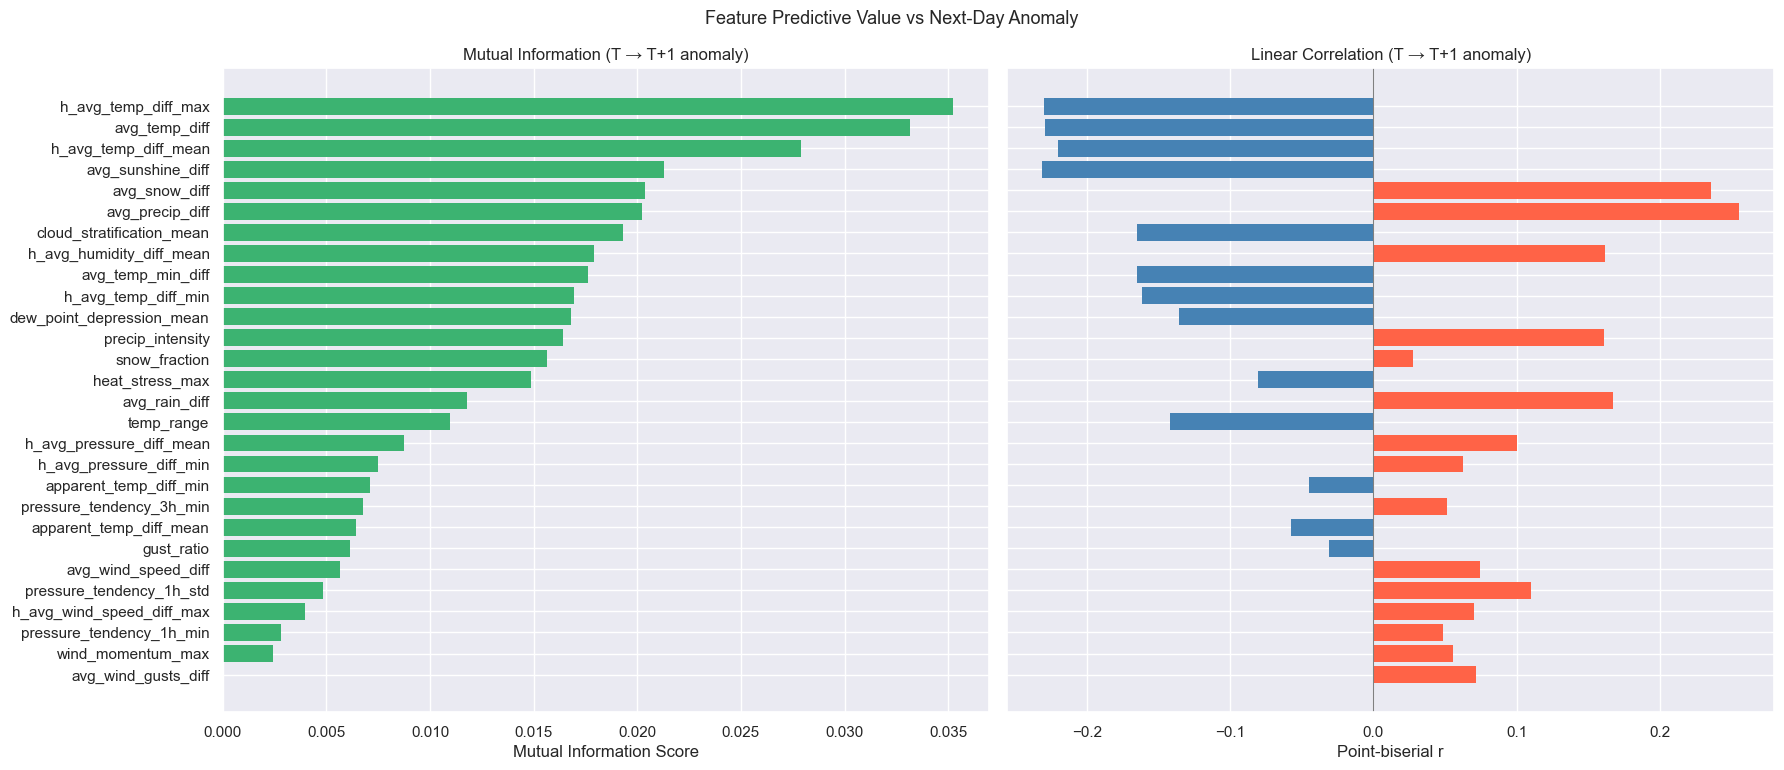

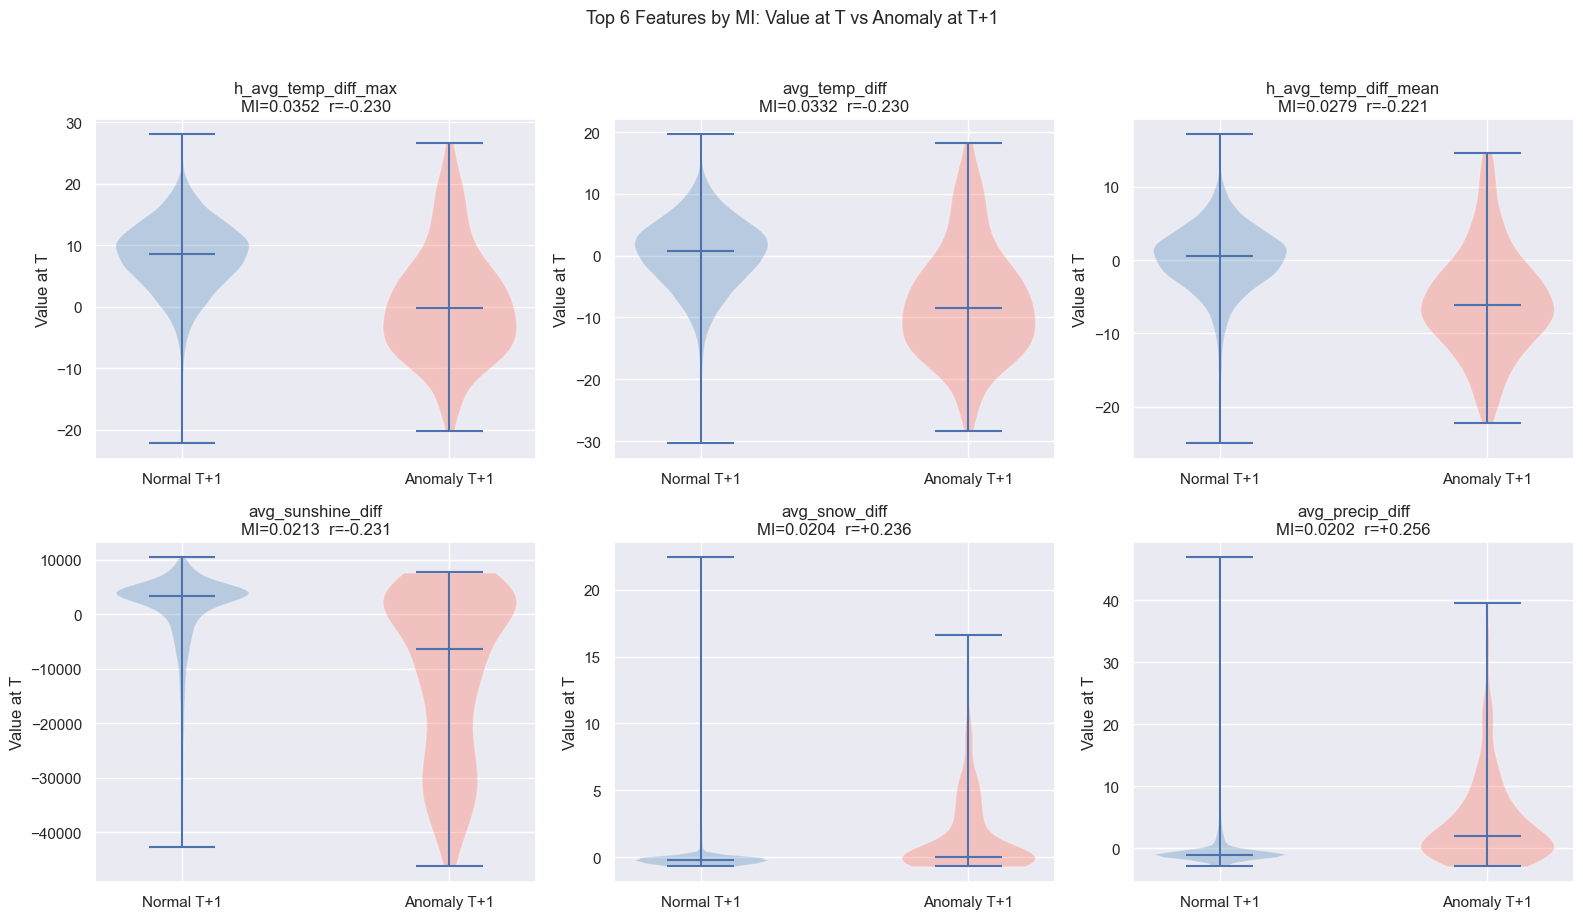

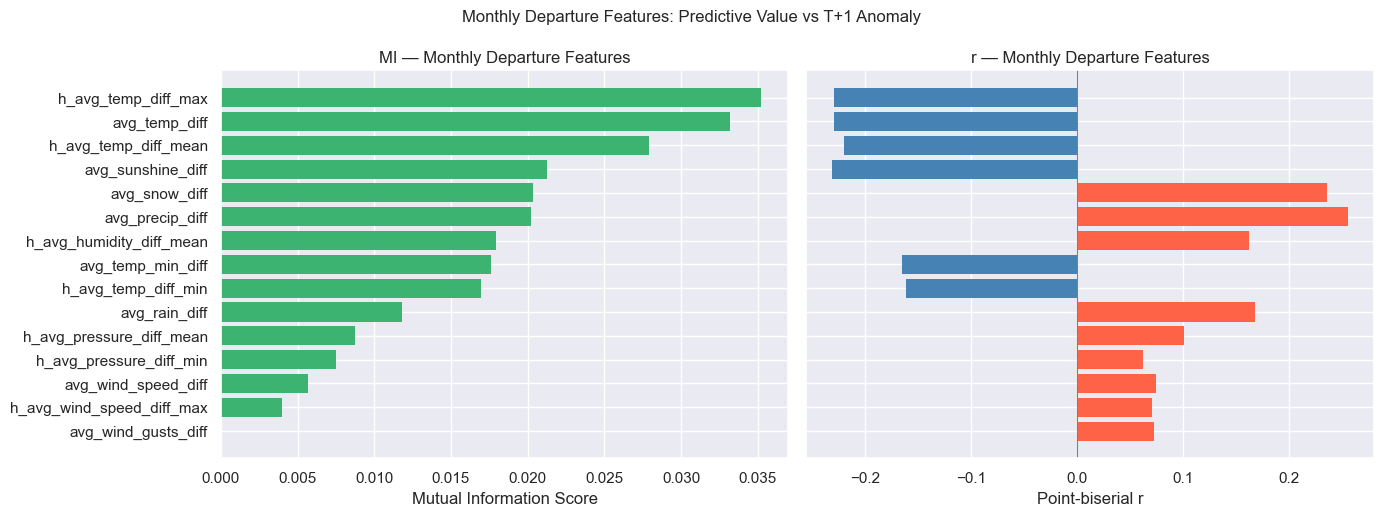

In [40]:
from sklearn.feature_selection import mutual_info_classif

# ── Aggregate hourly compounds + monthly departures to daily ──────────────────
# origin=daily_df.index[0] aligns 24-h bins to 06:00 UTC to match the daily index
_origin = daily_df.index[0]

hourly_daily_agg = hourly_df[compound_vars_hourly].resample("24h", origin=_origin).agg({
    "apparent_temp_diff":    ["mean", "min"],
    "dew_point_depression":  "mean",
    "pressure_tendency_1h":  ["min", "std"],
    "pressure_tendency_3h":  "min",
    "wind_momentum":         "max",
    "cloud_stratification":  "mean",
    "heat_stress":           "max",
})
hourly_daily_agg.columns = ["_".join(c) for c in hourly_daily_agg.columns]

hourly_avg_agg = hourly_df[avg_diff_vars_hourly].resample("24h", origin=_origin).agg({
    "avg_temp_diff":       ["mean", "min", "max"],
    "avg_pressure_diff":   ["mean", "min"],
    "avg_wind_speed_diff": "max",
    "avg_humidity_diff":   "mean",
})
hourly_avg_agg.columns = ["h_" + "_".join(c) for c in hourly_avg_agg.columns]

# next_day_anomaly was added to daily_df in §4 — each row's label is tomorrow's flag
compound_analysis = (
    daily_df[compound_vars_daily + avg_diff_vars_daily + ["next_day_anomaly"]]
    .join(hourly_daily_agg, how="left")
    .join(hourly_avg_agg,   how="left")
    .dropna(subset=["next_day_anomaly"])
)

feature_cols = [c for c in compound_analysis.columns if c != "next_day_anomaly"]

# ── Build clean MI matrix ─────────────────────────────────────────────────────
# Step 1: drop columns that are entirely NaN (catches any remaining join misalignment)
# Step 2: drop rows that still have any NaN across the surviving columns
mi_df = compound_analysis[feature_cols + ["next_day_anomaly"]].copy()
mi_df = mi_df.dropna(axis=1, how="all")
mi_df = mi_df.dropna()

mi_feature_cols = [c for c in mi_df.columns if c != "next_day_anomaly"]
print(f"MI matrix: {len(mi_df):,} rows × {len(mi_feature_cols)} features  "
      f"(dropped {len(feature_cols) - len(mi_feature_cols)} all-NaN columns, "
      f"{len(compound_analysis) - len(mi_df)} incomplete rows)")

X_mi      = mi_df[mi_feature_cols].values
y_mi      = mi_df["next_day_anomaly"].astype(int).values
mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_map    = dict(zip(mi_feature_cols, mi_scores))

# ── Point-biserial r (per-column, tolerates individual NaNs) ──────────────────
results = []
for col in feature_cols:
    valid = compound_analysis[[col, "next_day_anomaly"]].dropna()
    if valid["next_day_anomaly"].nunique() < 2:
        continue
    r, p = pointbiserialr(valid["next_day_anomaly"].astype(int), valid[col])
    results.append({"variable": col, "r": r, "p_value": p,
                    "mutual_info": mi_map.get(col, np.nan)})

results_df = pd.DataFrame(results).sort_values("mutual_info", ascending=False)

print("\nPredictive scores vs next_day_anomaly (T → T+1):\n")
print(results_df.to_string(index=False))

# ── Combined side-by-side bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(results_df) * 0.28)), sharey=True)
sorted_mi = results_df.sort_values("mutual_info", ascending=True)

axes[0].barh(sorted_mi["variable"], sorted_mi["mutual_info"],
             color="mediumseagreen", edgecolor="none")
axes[0].set_xlabel("Mutual Information Score")
axes[0].set_title("Mutual Information (T → T+1 anomaly)")

r_colors = ["tomato" if r >= 0 else "steelblue" for r in sorted_mi["r"]]
axes[1].barh(sorted_mi["variable"], sorted_mi["r"], color=r_colors, edgecolor="none")
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_xlabel("Point-biserial r")
axes[1].set_title("Linear Correlation (T → T+1 anomaly)")

plt.suptitle("Feature Predictive Value vs Next-Day Anomaly", fontsize=13)
plt.tight_layout()

# ── Violin plots: top 6 by MI ─────────────────────────────────────────────────
top_vars = results_df.dropna(subset=["mutual_info"]).head(6)["variable"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_vars):
    data_norm = compound_analysis.loc[compound_analysis["next_day_anomaly"] == False, col].dropna()
    data_anom = compound_analysis.loc[compound_analysis["next_day_anomaly"] == True,  col].dropna()
    parts = ax.violinplot([data_norm.values, data_anom.values], positions=[0, 1], showmedians=True)
    parts["bodies"][0].set_facecolor("steelblue")
    parts["bodies"][1].set_facecolor("tomato")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal T+1", "Anomaly T+1"])
    mi_val = mi_map.get(col, float("nan"))
    r_val  = results_df.loc[results_df["variable"] == col, "r"].values[0]
    ax.set_title(f"{col}\nMI={mi_val:.4f}  r={r_val:+.3f}")
    ax.set_ylabel("Value at T")

plt.suptitle("Top 6 Features by MI: Value at T vs Anomaly at T+1", y=1.02, fontsize=13)
plt.tight_layout()

# ── Monthly departure vars only: MI + r ───────────────────────────────────────
avg_cols    = [c for c in results_df["variable"] if "avg_" in c or c.startswith("h_avg_")]
avg_results = results_df[results_df["variable"].isin(avg_cols)].sort_values("mutual_info", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(avg_results) * 0.35)), sharey=True)

axes[0].barh(avg_results["variable"], avg_results["mutual_info"],
             color="mediumseagreen", edgecolor="none")
axes[0].set_xlabel("Mutual Information Score")
axes[0].set_title("MI — Monthly Departure Features")

r_colors = ["tomato" if r >= 0 else "steelblue" for r in avg_results["r"]]
axes[1].barh(avg_results["variable"], avg_results["r"], color=r_colors, edgecolor="none")
axes[1].axvline(0, color="gray", lw=0.8)
axes[1].set_xlabel("Point-biserial r")
axes[1].set_title("r — Monthly Departure Features")

plt.suptitle("Monthly Departure Features: Predictive Value vs T+1 Anomaly", fontsize=12)
plt.tight_layout()

## 10. DataFrame Cleaning
Drop all-null columns and redundant highly-correlated features identified in §§2, 5, and 8.
Produces `hourly_clean` and `daily_clean` ready for feature engineering.

In [41]:
# Hourly: drop all-null columns (no data from API for this location/period)
ALL_NULL_HOURLY = [
    "wind_speed_80m",
    "cape",
    "freezing_level_height",
    "visibility",
    "temperature_850hPa",
    "relative_humidity_850hPa",
    "wind_speed_850hPa",
    "geopotential_height_850hPa",
    "temperature_500hPa",
    "wind_speed_500hPa",
    "geopotential_height_500hPa",
    "wind_speed_300hPa",
    "geopotential_height_300hPa",
]

# apparent_temperature: retained — §8 shows the diff carries signal beyond raw temp
# showers: all-zero but structurally valid; keep as a zero-valued indicator
hourly_clean = hourly_df.drop(columns=ALL_NULL_HOURLY)

print(f"Hourly: {hourly_df.shape} → {hourly_clean.shape}")
print(f"Dropped: {ALL_NULL_HOURLY}")
hourly_clean.info()

Hourly: (143280, 44) → (143280, 31)
Dropped: ['wind_speed_80m', 'cape', 'freezing_level_height', 'visibility', 'temperature_850hPa', 'relative_humidity_850hPa', 'wind_speed_850hPa', 'geopotential_height_850hPa', 'temperature_500hPa', 'wind_speed_500hPa', 'geopotential_height_500hPa', 'wind_speed_300hPa', 'geopotential_height_300hPa']
<class 'pandas.DataFrame'>
DatetimeIndex: 143280 entries, 2010-01-01 06:00:00+00:00 to 2026-05-07 05:00:00+00:00
Data columns (total 31 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   temperature_2m           143280 non-null  float64
 1   apparent_temperature     143280 non-null  float64
 2   dew_point_2m             143280 non-null  float64
 3   relative_humidity_2m     143280 non-null  float64
 4   precipitation            143280 non-null  float64
 5   rain                     143280 non-null  float64
 6   showers                  143280 non-null  float64
 7   snowfall          

In [42]:
# Daily: drop all-null columns
ALL_NULL_DAILY = ["precipitation_probability_max", "uv_index_max"]

# Drop redundant temperature columns (r > 0.97 with temperature_2m_max/min):
#   apparent_temperature_max/min → highly correlated (r > 0.99); use compound diff instead
#   temperature_2m_mean          → r > 0.97 with both max and min
# Drop precipitation_sum: implied by rain_sum + snowfall_sum (r = 0.85)
REDUNDANT_DAILY = [
    "apparent_temperature_max",
    "apparent_temperature_min",
    "temperature_2m_mean",
    "precipitation_sum",
]

daily_clean = daily_df.drop(columns=ALL_NULL_DAILY + REDUNDANT_DAILY)

print(f"Daily: {daily_df.shape} → {daily_clean.shape}")
print(f"Dropped null columns:      {ALL_NULL_DAILY}")
print(f"Dropped redundant columns: {REDUNDANT_DAILY}")
daily_clean.info()

Daily: (5970, 33) → (5970, 27)
Dropped null columns:      ['precipitation_probability_max', 'uv_index_max']
Dropped redundant columns: ['apparent_temperature_max', 'apparent_temperature_min', 'temperature_2m_mean', 'precipitation_sum']
<class 'pandas.DataFrame'>
DatetimeIndex: 5970 entries, 2010-01-01 06:00:00+00:00 to 2026-05-06 06:00:00+00:00
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_2m_max           5970 non-null   float64
 1   temperature_2m_min           5970 non-null   float64
 2   rain_sum                     5970 non-null   float64
 3   snowfall_sum                 5970 non-null   float64
 4   precipitation_hours          5970 non-null   float64
 5   wind_speed_10m_max           5970 non-null   float64
 6   wind_gusts_10m_max           5970 non-null   float64
 7   wind_direction_10m_dominant  5970 non-null   float64
 8   sunshine_duration            5970 n